In [1]:
import os
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

print("=== CAPSTONE EVALUATION - RUNDE 1 (MODUL 12) ===")
print("Generiere Portal-Eingaben für alle 8 Funktionen...\n")

for i in range(1, 9):
    # Pfade exakt basierend auf Ihrer Struktur ansteuern
    folder_path = os.path.join('initial_data', f'function_{i}')
    inputs_path = os.path.join(folder_path, 'initial_inputs.npy')
    outputs_path = os.path.join(folder_path, 'initial_outputs.npy')
    
    # Sicherheitscheck ob die Ordner da sind
    if not os.path.exists(inputs_path) or not os.path.exists(outputs_path):
        print(f"❌ Funktion {i}: Daten unter '{folder_path}' nicht gefunden. Bitte Ordner prüfen!")
        continue
        
    X_f = np.load(inputs_path)
    y_f = np.load(outputs_path)
    
    # Die Dimensionalität (2D bis 8D) wird hier automatisch aus den Daten gelesen!
    dim = X_f.shape[1]
    
    # 50.000 Zufallspunkte für den gesamten Raum generieren (Monte Carlo Methode für hohe Dimensionen)
    np.random.seed(42 + i)
    X_grid = np.random.uniform(0.0, 1.0, size=(50000, dim))
    
    try:
        # Gauß-Prozess mit festem Radius, um den 0.0-Crash in der Null-Landschaft zu verhindern
        kernel = Matern(length_scale=[0.2] * dim, nu=2.5)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, optimizer=None)
        gp.fit(X_f, y_f)
        
        mean, sigma = gp.predict(X_grid, return_std=True)
        beta = 3.0  # Starke Exploration (Erkundung) für die allererste Woche
        ucb_values = mean + beta * sigma
        best_idx = np.argmax(ucb_values)
        next_point = X_grid[best_idx]
        
    except Exception:
        # Absolutes Sicherheitsnetz: Falls das Modell bei reinen Nullen komplett streikt,
        # wählen wir rein mathematisch den Punkt, der am weitesten von allen 10 Startpunkten entfernt ist!
        from scipy.spatial.distance import cdist
        distances = cdist(X_grid, X_f)
        min_distances = np.min(distances, axis=1)
        best_idx = np.argmax(min_distances)
        next_point = X_grid[best_idx]
    
    # String für das Portal formatieren (x1-x2-x3... mit 6 Dezimalstellen)
    portal_string = "-".join([f"{val:.6f}" for val in next_point])
    print(f"Funktion {i} ({dim}D) ➡️ {portal_string}")

print("\n========================================================")
print("Kopieren Sie diese 8 Zeilen nun in Ihr Capstone-Portal!")

=== CAPSTONE EVALUATION - RUNDE 1 (MODUL 12) ===
Generiere Portal-Eingaben für alle 8 Funktionen...

Funktion 1 (2D) ➡️ 0.918961-0.813933
Funktion 2 (2D) ➡️ 0.854791-0.997925
Funktion 3 (3D) ➡️ 0.400793-0.080342-0.469810
Funktion 4 (4D) ➡️ 0.415468-0.461440-0.442922-0.368468
Funktion 5 (4D) ➡️ 0.278305-0.792622-0.863880-0.957522
Funktion 6 (5D) ➡️ 0.670505-0.280118-0.572168-0.742180-0.130406
Funktion 7 (6D) ➡️ 0.115521-0.457767-0.253082-0.105120-0.406877-0.740962
Funktion 8 (8D) ➡️ 0.005559-0.111415-0.028853-0.097486-0.389908-0.851347-0.380352-0.730005

Kopieren Sie diese 8 Zeilen nun in Ihr Capstone-Portal!


C:\Users\Die Gruenen\AppData\Local\Temp\ipykernel_12724\1305511875.py:52: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


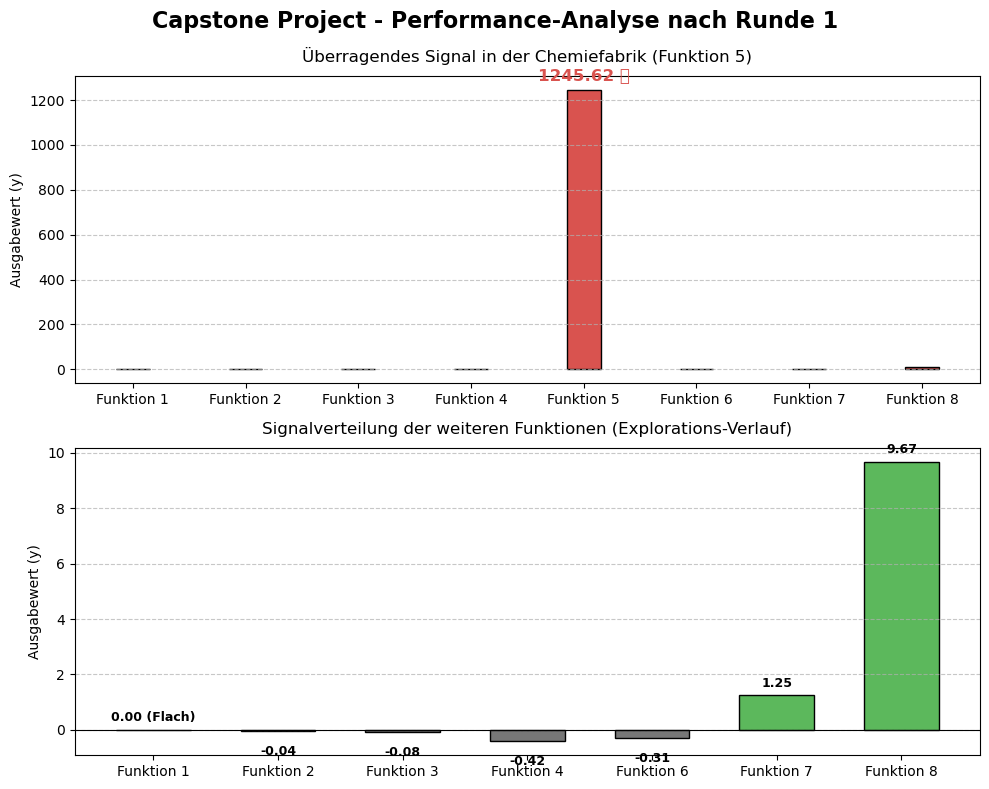

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Ihre echten Rückgabewerte aus Runde 1
functions_all = [f"Funktion {i}" for i in range(1, 9)]
y_values = [
    1.5923609430044094e-83, # F1
    -0.03919264506585562,   # F2
    -0.0767527695811551,    # F3
    -0.41512342658825174,   # F4
    1245.6226302947089,     # F5
    -0.31128547419044217,   # F6
    1.2450678353842874,     # F7
    9.6729468693385         # F8
]

# Erstellung einer Multi-Plot-Ansicht (2 Zeilen, 1 Spalte)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle('Capstone Project - Performance-Analyse nach Runde 1', fontsize=16, fontweight='bold')

# --- DIAGRAMM 1: Fokus auf den Riesenerfolg von Funktion 5 ---
ax1.bar(functions_all, y_values, color='#d9534f', edgecolor='black', width=0.3)
ax1.set_title('Überragendes Signal in der Chemiefabrik (Funktion 5)', fontsize=12, pad=10)
ax1.set_ylabel('Ausgabewert (y)', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
# Textlabel direkt über den Balken setzen (Hier war der Fehler korrigiert!)
ax1.text(4, y_values[4] + 30, f'{y_values[4]:.2f} 🔥', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#d9534f')

# --- DIAGRAMM 2: Die restlichen 7 Funktionen im Detail ---
rest_functions = [functions_all[i] for i in range(8) if i != 4]
rest_values = [y_values[i] for i in range(8) if i != 4]

# Farbkodierung: Grün für klar positive Signale, Grau für Werte nahe Null
colors = ['#777777', '#777777', '#777777', '#777777', '#777777', '#5cb85c', '#5cb85c']

bars = ax2.bar(rest_functions, rest_values, color=colors, edgecolor='black', width=0.6)
ax2.set_title('Signalverteilung der weiteren Funktionen (Explorations-Verlauf)', fontsize=12, pad=10)
ax2.set_ylabel('Ausgabewert (y)', fontsize=10)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='-') # Nulllinie zur Orientierung
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Werte an den Balken anzeigen
for bar in bars:
    height = bar.get_height()
    # Platzierung des Textes optimieren, je nachdem ob der Wert positiv oder negativ ist
    va_dir = 'bottom' if height >= 0 else 'top'
    xy_offset = 0.2 if height >= 0 else -0.5
    ax2.text(bar.get_x() + bar.get_width()/2., height + xy_offset,
             f'{height:.2f}' if abs(height) > 1e-5 else '0.00 (Flach)',
             ha='center', va=va_dir, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
import os
import numpy as np

print("=== UPDATE: HÄNGE NEUE MESSWERTE AN ALLE 8 FUNKTIONEN AN ===")

# Die exakten Werte aus Ihrer Ergebnis-E-Mail (Eingaben und Ausgaben)
neue_inputs = {
    1: np.array([0.918961, 0.813933]),
    2: np.array([0.854791, 0.997925]),
    3: np.array([0.400793, 0.080342, 0.469810]),
    4: np.array([0.415468, 0.461440, 0.442922, 0.368468]),
    5: np.array([0.278305, 0.792622, 0.863880, 0.957522]),
    6: np.array([0.670505, 0.280118, 0.572168, 0.742180, 0.130406]),
    7: np.array([0.115521, 0.457767, 0.253082, 0.105120, 0.406877, 0.740962]),
    8: np.array([0.005559, 0.111415, 0.028853, 0.097486, 0.389908, 0.851347, 0.380352, 0.730005])
}

neue_outputs = {
    1: 1.5923609430044094e-83,
    2: -0.03919264506585562,
    3: -0.0767527695811551,
    4: -0.41512342658825174,
    5: 1245.6226302947089,
    6: -0.31128547419044217,
    7: 1.2450678353842874,
    8: 9.6729468693385
}

# Schleife erweitert nun jede Funktion bedingungslos um genau eine Zeile
for i in range(1, 9):
    folder_path = os.path.join('initial_data', f'function_{i}')
    inputs_path = os.path.join(folder_path, 'initial_inputs.npy')
    outputs_path = os.path.join(folder_path, 'initial_outputs.npy')
    
    # Bestehende Daten laden
    X_alt = np.load(inputs_path)
    y_alt = np.load(outputs_path)
    
    # Neue Zeilen formatieren
    X_neu = neue_inputs[i].reshape(1, -1)
    y_neu = np.array([neue_outputs[i]])
    
    # Unten anfügen
    X_erweitert = np.vstack([X_alt, X_neu])
    y_erweitert = np.concatenate([y_alt, y_neu])
    
    # Überspeichern auf der Festplatte
    np.save(inputs_path, X_erweitert)
    np.save(outputs_path, y_erweitert)
    print(f"✅ Funktion {i}: Erfolgreich erweitert! Neue Gesamtzahl: {X_erweitert.shape[0]} Datenpunkte.")

print("========================================================")
print("Ihre gesamte Datenbasis ist jetzt auf dem aktuellsten Stand!")

=== UPDATE: HÄNGE NEUE MESSWERTE AN ALLE 8 FUNKTIONEN AN ===
✅ Funktion 1: Erfolgreich erweitert! Neue Gesamtzahl: 12 Datenpunkte.
✅ Funktion 2: Erfolgreich erweitert! Neue Gesamtzahl: 12 Datenpunkte.
✅ Funktion 3: Erfolgreich erweitert! Neue Gesamtzahl: 17 Datenpunkte.
✅ Funktion 4: Erfolgreich erweitert! Neue Gesamtzahl: 32 Datenpunkte.
✅ Funktion 5: Erfolgreich erweitert! Neue Gesamtzahl: 22 Datenpunkte.
✅ Funktion 6: Erfolgreich erweitert! Neue Gesamtzahl: 22 Datenpunkte.
✅ Funktion 7: Erfolgreich erweitert! Neue Gesamtzahl: 32 Datenpunkte.
✅ Funktion 8: Erfolgreich erweitert! Neue Gesamtzahl: 42 Datenpunkte.
Ihre gesamte Datenbasis ist jetzt auf dem aktuellsten Stand!


In [7]:
import os
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

print("=== CAPSTONE EVALUATION - RUNDE 2 (WOCHE 2 / NEUE ABGABE) ===")
print("Berechne maßgeschneiderte Portal-Eingaben basierend auf Runde 1...\n")

for i in range(1, 9):
    folder_path = os.path.join('initial_data', f'function_{i}')
    inputs_path = os.path.join(folder_path, 'initial_inputs.npy')
    outputs_path = os.path.join(folder_path, 'initial_outputs.npy')
    
    if not os.path.exists(inputs_path) or not os.path.exists(outputs_path):
        print(f"❌ Funktion {i}: Daten unter '{folder_path}' nicht gefunden!")
        continue
        
    X_f = np.load(inputs_path)
    y_f = np.load(outputs_path)
    
    # Automatische Ermittlung der echten Dimensionalität (Spaltenanzahl)
    dim = X_f.shape[1] if len(X_f.shape) > 1 else 1
    
    # Den bisher besten bekannten Wert ermitteln
    current_best_y = np.max(y_f)
    
    # --- STRATEGIE-ANPASSUNG FÜR DIE GRUPPEN (Ihre angekündigte Policy) ---
    if i == 5:
        # Aggressive Ausbeutung (Exploitation) für den Riesentreffer bei Funktion 5
        beta = 0.3
        strategy_text = "Aggressive Exploitation (Gipfelsturm)"
    elif i in [1, 2]:
        # Starke Exploration für flache Landschaften (F1 und F2) - KORRIGIERT!
        beta = 3.0
        strategy_text = "Sustained Exploration (Lückensuche)"
    else:
        # Ausgewogene Strategie für die mittleren/hohen Dimensionen (F3, F4, F6, F7, F8)
        beta = 1.5
        strategy_text = "Balanced Exploration/Exploitation"
        
    # 50.000 Testpunkte würfeln
    np.random.seed(200 + i) # Einzigartiger, neuer Seed für Runde 2
    X_grid = np.random.uniform(0.0, 1.0, size=(50000, dim))
    
    try:
        kernel = Matern(length_scale=[0.2] * dim, nu=2.5)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, optimizer=None)
        gp.fit(X_f, y_f)
        
        mean, sigma = gp.predict(X_grid, return_std=True)
        ucb_values = mean + beta * sigma
        best_idx = np.argmax(ucb_values)
        next_point = X_grid[best_idx]
        
    except Exception:
        # Sicherheitsnetz bei numerischen Ausreißern
        from scipy.spatial.distance import cdist
        distances = cdist(X_grid, X_f)
        min_distances = np.min(distances, axis=1)
        best_idx = np.argmax(min_distances)
        next_point = X_grid[best_idx]
        strategy_text = "Fallback Space-Filling Exploration"
    
    # String für das Portal formatieren (6 Dezimalstellen, Trennung durch Bindestrich)
    portal_string = "-".join([f"{val:.6f}" for val in next_point])
    print(f"Funktion {i} ({dim}D) ➡️ {portal_string} | {strategy_text} (Bestes y: {current_best_y:.2f})")

print("\n========================================================")
print("Kopieren Sie diese 8 neuen Zeilen in Ihr Capstone-Portal!")

=== CAPSTONE EVALUATION - RUNDE 2 (WOCHE 2 / NEUE ABGABE) ===
Berechne maßgeschneiderte Portal-Eingaben basierend auf Runde 1...

Funktion 1 (2D) ➡️ 0.332795-0.999422 | Sustained Exploration (Lückensuche) (Bestes y: 0.00)
Funktion 2 (2D) ➡️ 0.558162-0.999819 | Sustained Exploration (Lückensuche) (Bestes y: 0.61)
Funktion 3 (3D) ➡️ 0.391337-0.409893-0.469964 | Balanced Exploration/Exploitation (Bestes y: -0.03)
Funktion 4 (4D) ➡️ 0.362578-0.364249-0.412471-0.286251 | Balanced Exploration/Exploitation (Bestes y: -0.42)
Funktion 5 (4D) ➡️ 0.296248-0.792688-0.884247-0.965300 | Aggressive Exploitation (Gipfelsturm) (Bestes y: 1245.62)
Funktion 6 (5D) ➡️ 0.731437-0.260981-0.480227-0.777828-0.109331 | Balanced Exploration/Exploitation (Bestes y: -0.31)
Funktion 7 (6D) ➡️ 0.018144-0.430926-0.176889-0.202111-0.422628-0.734029 | Balanced Exploration/Exploitation (Bestes y: 1.36)
Funktion 8 (8D) ➡️ 0.103520-0.178618-0.145706-0.030181-0.477393-0.716238-0.372373-0.731798 | Balanced Exploration/Expl

In [1]:
import os
import numpy as np

print("=== UPDATE: HÄNGE MESSWERTE AUS RUNDE 2 AN ALLE 8 FUNKTIONEN AN ===")

# Die exakten neuen Werte aus Ihrer aktuellen Ergebnis-E-Mail
neue_inputs = {
    1: np.array([0.332795, 0.999422]),
    2: np.array([0.558162, 0.999819]),
    3: np.array([0.391337, 0.409893, 0.469964]),
    4: np.array([0.362578, 0.364249, 0.412471, 0.286251]),
    5: np.array([0.296248, 0.792688, 0.884247, 0.965300]),
    6: np.array([0.731437, 0.260981, 0.480227, 0.777828, 0.109331]),
    7: np.array([0.018144, 0.430926, 0.176889, 0.202111, 0.422628, 0.734029]),
    8: np.array([0.103520, 0.178618, 0.145706, 0.030181, 0.477393, 0.716238, 0.372373, 0.731798])
}

neue_outputs = {
    1: -4.167201393697201e-157,
    2: 0.04988590099041905,
    3: -0.006625612773487244,
    4: -0.9531920599943713,
    5: 1405.5491522086859,
    6: -0.5537433707876842,
    7: 1.3457853758490064,
    8: 9.8241011168001
}

for i in range(1, 9):
    folder_path = os.path.join('initial_data', f'function_{i}')
    inputs_path = os.path.join(folder_path, 'initial_inputs.npy')
    outputs_path = os.path.join(folder_path, 'initial_outputs.npy')
    
    X_alt = np.load(inputs_path)
    y_alt = np.load(outputs_path)
    
    X_neu = neue_inputs[i].reshape(1, -1)
    y_neu = np.array([neue_outputs[i]])
    
    X_erweitert = np.vstack([X_alt, X_neu])
    y_erweitert = np.concatenate([y_alt, y_neu])
    
    np.save(inputs_path, X_erweitert)
    np.save(outputs_path, y_erweitert)
    print(f"✅ Funktion {i}: Erfolgreich erweitert! Neue Gesamtzahl: {X_erweitert.shape} Datenpunkte.")

print("========================================================")

=== UPDATE: HÄNGE MESSWERTE AUS RUNDE 2 AN ALLE 8 FUNKTIONEN AN ===
✅ Funktion 1: Erfolgreich erweitert! Neue Gesamtzahl: (13, 2) Datenpunkte.
✅ Funktion 2: Erfolgreich erweitert! Neue Gesamtzahl: (13, 2) Datenpunkte.
✅ Funktion 3: Erfolgreich erweitert! Neue Gesamtzahl: (18, 3) Datenpunkte.
✅ Funktion 4: Erfolgreich erweitert! Neue Gesamtzahl: (33, 4) Datenpunkte.
✅ Funktion 5: Erfolgreich erweitert! Neue Gesamtzahl: (23, 4) Datenpunkte.
✅ Funktion 6: Erfolgreich erweitert! Neue Gesamtzahl: (23, 5) Datenpunkte.
✅ Funktion 7: Erfolgreich erweitert! Neue Gesamtzahl: (33, 6) Datenpunkte.
✅ Funktion 8: Erfolgreich erweitert! Neue Gesamtzahl: (43, 8) Datenpunkte.


In [8]:
import os
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

print("=== CAPSTONE EVALUATION - RUNDE 3 (WOCHE 3 / NEUE ABGABE) ===")
print("Berechne maßgeschneiderte Portal-Eingaben basierend auf Runde 2...\n")

for i in range(1, 9):
    folder_path = os.path.join('initial_data', f'function_{i}')
    inputs_path = os.path.join(folder_path, 'initial_inputs.npy')
    outputs_path = os.path.join(folder_path, 'initial_outputs.npy')
    
    if not os.path.exists(inputs_path) or not os.path.exists(outputs_path):
        print(f"❌ Funktion {i}: Daten unter '{folder_path}' nicht gefunden!")
        continue
        
    X_f = np.load(inputs_path)
    y_f = np.load(outputs_path)
    
    dim = X_f.shape[1] if len(X_f.shape) > 1 else 1
    current_best_y = np.max(y_f)
    
    # --- TAILORED ACQUISITION PARAMETERS FÜR RUNDEN-KLASSIFIZIERUNG ---
    if i == 5:
        beta = 0.1  # Maximale Intensivierung des Gipfelsturms
        strategy_text = "Hyper-Exploitation (Lokale Peak-Verfeinerung)"
    elif i in [1, 2]:
        beta = 3.5  # Erhöhter Explorationsdruck für die Null-Landschaft
        strategy_text = "Aggressive Exploration (Radikale Lückensuche)"
    else:
        beta = 1.2  # Leicht erhöhte Reife zur Ausbeutung der stabilen hohen Dimensionen
        strategy_text = "Balanced Exploitation-Focused Policy"
        
    np.random.seed(300 + i) # Einzigartiger Seed für Runde 3
    X_grid = np.random.uniform(0.0, 1.0, size=(50000, dim))
    
    try:
        kernel = Matern(length_scale=[0.2] * dim, nu=2.5)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, optimizer=None)
        gp.fit(X_f, y_f)
        
        mean, sigma = gp.predict(X_grid, return_std=True)
        ucb_values = mean + beta * sigma
        best_idx = np.argmax(ucb_values)
        next_point = X_grid[best_idx]
        
    except Exception:
        from scipy.spatial.distance import cdist
        distances = cdist(X_grid, X_f)
        min_distances = np.min(distances, axis=1)
        best_idx = np.argmax(min_distances)
        next_point = X_grid[best_idx]
        strategy_text = "Fallback Space-Filling Exploration"
    
    portal_string = "-".join([f"{val:.6f}" for val in next_point])
    print(f"Funktion {i} ({dim}D) ➡️ {portal_string} | {strategy_text} (Bestes y: {current_best_y:.2f})")

print("\n========================================================")
print("Kopieren Sie diese 8 neuen Zeilen in Ihr Capstone-Portal!")

=== CAPSTONE EVALUATION - RUNDE 3 (WOCHE 3 / NEUE ABGABE) ===
Berechne maßgeschneiderte Portal-Eingaben basierend auf Runde 2...

Funktion 1 (2D) ➡️ 0.000479-0.785364 | Aggressive Exploration (Radikale Lückensuche) (Bestes y: 0.00)
Funktion 2 (2D) ➡️ 0.892620-0.052503 | Aggressive Exploration (Radikale Lückensuche) (Bestes y: 0.61)
Funktion 3 (3D) ➡️ 0.442904-0.541451-0.493673 | Balanced Exploitation-Focused Policy (Bestes y: -0.01)
Funktion 4 (4D) ➡️ 0.431634-0.432912-0.514607-0.264107 | Balanced Exploitation-Focused Policy (Bestes y: -0.42)
Funktion 5 (4D) ➡️ 0.320637-0.791333-0.947010-0.960370 | Hyper-Exploitation (Lokale Peak-Verfeinerung) (Bestes y: 1405.55)
Funktion 6 (5D) ➡️ 0.612020-0.260334-0.563093-0.669122-0.096984 | Balanced Exploitation-Focused Policy (Bestes y: -0.31)
Funktion 7 (6D) ➡️ 0.121939-0.466771-0.188533-0.225892-0.483073-0.715500 | Balanced Exploitation-Focused Policy (Bestes y: 1.36)
Funktion 8 (8D) ➡️ 0.139236-0.164721-0.200203-0.012874-0.507685-0.786236-0.369

In [1]:
import os
import numpy as np

print("=== UPDATE: HÄNGE MESSWERTE AUS RUNDE 3 AN ALLE 8 FUNKTIONEN AN ===")

# Die exakten neuen Eingabe-Koordinaten dieser Woche
neue_inputs = {
    1: np.array([0.000479, 0.785364]),
    2: np.array([0.892620, 0.052503]),
    3: np.array([0.442904, 0.541451, 0.493673]),
    4: np.array([0.431634, 0.432912, 0.514607, 0.264107]),
    5: np.array([0.320637, 0.791333, 0.947010, 0.960370]),
    6: np.array([0.612020, 0.260334, 0.563093, 0.669122, 0.096984]),
    7: np.array([0.121939, 0.466771, 0.188533, 0.225892, 0.483073, 0.715500]),
    8: np.array([0.139236, 0.164721, 0.200203, 0.012874, 0.507685, 0.786236, 0.369720, 0.908568])
}

# Die exakten neuen Messergebnisse aus Ihrer aktuellen E-Mail
neue_outputs = {
    1: 1.1766886889889866e-216,
    2: 0.11645535367358874,
    3: -0.015012705134294048,
    4: -2.3152903050861506,
    5: 1770.8698342302364,
    6: -0.5290192580928266,
    7: 1.1007949459564847,
    8: 9.7713291860931
}

for i in range(1, 9):
    folder_path = os.path.join('initial_data', f'function_{i}')
    inputs_path = os.path.join(folder_path, 'initial_inputs.npy')
    outputs_path = os.path.join(folder_path, 'initial_outputs.npy')
    
    X_alt = np.load(inputs_path)
    y_alt = np.load(outputs_path)
    
    X_neu = neue_inputs[i].reshape(1, -1)
    y_neu = np.array([neue_outputs[i]])
    
    X_erweitert = np.vstack([X_alt, X_neu])
    y_erweitert = np.concatenate([y_alt, y_neu])
    
    np.save(inputs_path, X_erweitert)
    np.save(outputs_path, y_erweitert)
    print(f"✅ Funktion {i}: Datensatz erfolgreich auf {X_erweitert.shape[0]} Punkte erweitert!")

print("========================================================")

=== UPDATE: HÄNGE MESSWERTE AUS RUNDE 3 AN ALLE 8 FUNKTIONEN AN ===
✅ Funktion 1: Datensatz erfolgreich auf 14 Punkte erweitert!
✅ Funktion 2: Datensatz erfolgreich auf 14 Punkte erweitert!
✅ Funktion 3: Datensatz erfolgreich auf 19 Punkte erweitert!
✅ Funktion 4: Datensatz erfolgreich auf 34 Punkte erweitert!
✅ Funktion 5: Datensatz erfolgreich auf 24 Punkte erweitert!
✅ Funktion 6: Datensatz erfolgreich auf 24 Punkte erweitert!
✅ Funktion 7: Datensatz erfolgreich auf 34 Punkte erweitert!
✅ Funktion 8: Datensatz erfolgreich auf 44 Punkte erweitert!


In [3]:
import os
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.svm import SVC

print("=== CAPSTONE EVALUATION - RUNDE 4 (WOCHE 4 / HYBRID GP-SVM BBO) ===")
print("Berechne Abfrage-Koordinaten unter SVM-Regionen-Filterung...\n")

for i in range(1, 9):
    folder_path = os.path.join('initial_data', f'function_{i}')
    inputs_path = os.path.join(folder_path, 'initial_inputs.npy')
    outputs_path = os.path.join(folder_path, 'initial_outputs.npy')
    
    if not os.path.exists(inputs_path) or not os.path.exists(outputs_path):
        print(f"❌ Funktion {i}: Daten unter '{folder_path}' nicht gefunden!")
        continue
        
    X_f = np.load(inputs_path)
    y_f = np.load(outputs_path)
    
    # Dimension auslesen (Spaltenanzahl des 2D-Arrays)
    dim = X_f.shape[1] if len(X_f.shape) > 1 else 1
    current_best_y = np.max(y_f)
    
    # 50.000 Testpunkte für Monte Carlo generieren
    np.random.seed(400 + i) # Einzigartiger Seed für Woche 4
    X_grid = np.random.uniform(0.0, 1.0, size=(50000, dim))
    
    # --- TAILORED ACQUISITION PARAMETERS ---
    if i == 5:
        beta = 0.1  # Fokus auf die absolute Spitze
        strategy_text = "GP-Exploitation + SVM-Gipfel-Fokus"
    elif i in [1, 2]:
        beta = 3.0  # Hohe Exploration für flache/verrauschte Räume
        strategy_text = "Pure GP-Exploration (Kein SVM-Filter)"
    else:
        beta = 1.2  # Ausgewogen für komplexe Räume
        strategy_text = "Hybrid GP-SVM Balanced Policy"
        
    try:
        # Gauß-Prozess trainieren
        kernel = Matern(length_scale=[0.2] * dim, nu=2.5)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, optimizer=None)
        gp.fit(X_f, y_f)
        
        # --- SOFT-MARGIN SVM REGIONEN-FILTERUNG (NUR FÜR F3, F4, F5, F6, F7, F8) ---
        # Wir filtern nur, wenn wir bereits genug Daten und ein klares Signal haben
        if i not in [1, 2] and len(y_f) >= 15:
            # Schwellenwert: Die besten 25% der bisherigen Punkte definieren die "Erfolgszone"
            threshold = np.percentile(y_f, 75)
            y_labels = np.where(y_f >= threshold, 1, 0)
            
            # Prüfen, ob wir mindestens zwei Klassen haben (notwendig für SVM)
            if len(np.unique(y_labels)) > 1:
                # Soft-Margin SVM mit RBF-Kernel initialisieren und fitten
                svm = SVC(kernel='rbf', C=1.0, gamma='scale')
                svm.fit(X_f, y_labels)
                
                # Vorhersage für alle 50.000 Monte-Carlo-Punkte extrahieren
                preds = svm.predict(X_grid)
                
                # Nur die Punkte behalten, die von der SVM als "vielversprechend" (Klasse 1) eingestuft werden
                X_filtered = X_grid[preds == 1]
                
                # Sicherheitsnetz: Falls die SVM zu streng war und alles weggeworfen hat
                if len(X_filtered) > 100:
                    X_grid_final = X_filtered
                    strategy_text += " [SVM Aktiv]"
                else:
                    X_grid_final = X_grid
            else:
                X_grid_final = X_grid
        else:
            X_grid_final = X_grid
            
        # UCB-Berechnung auf dem (eventuell gefilterten) Gitter durchführen
        mean, sigma = gp.predict(X_grid_final, return_std=True)
        ucb_values = mean + beta * sigma
        best_idx = np.argmax(ucb_values)
        next_point = X_grid_final[best_idx]
        
    except Exception as e:
        # Sicherheitsnetz bei numerischen Fehlern
        from scipy.spatial.distance import cdist
        distances = cdist(X_grid, X_f)
        min_distances = np.min(distances, axis=1)
        best_idx = np.argmax(min_distances)
        next_point = X_grid[best_idx]
        strategy_text = "Fallback Space-Filling Exploration"
    
    # Für das Portal formatieren
    portal_string = "-".join([f"{val:.6f}" for val in next_point])
    print(f"Funktion {i} ({dim}D) ➡️ {portal_string} | {strategy_text} (Bestes y: {current_best_y:.2f})")

print("\n========================================================")
print("Kopieren Sie diese 8 neuen Zeilen in Ihr Capstone-Portal!")

=== CAPSTONE EVALUATION - RUNDE 4 (WOCHE 4 / HYBRID GP-SVM BBO) ===
Berechne Abfrage-Koordinaten unter SVM-Regionen-Filterung...

Funktion 1 (2D) ➡️ 0.996925-0.004402 | Pure GP-Exploration (Kein SVM-Filter) (Bestes y: 0.00)
Funktion 2 (2D) ➡️ 0.712520-0.291144 | Pure GP-Exploration (Kein SVM-Filter) (Bestes y: 0.61)
Funktion 3 (3D) ➡️ 0.305374-0.479312-0.494263 | Hybrid GP-SVM Balanced Policy [SVM Aktiv] (Bestes y: -0.01)
Funktion 4 (4D) ➡️ 0.470343-0.362209-0.400861-0.363530 | Hybrid GP-SVM Balanced Policy [SVM Aktiv] (Bestes y: -0.42)
Funktion 5 (4D) ➡️ 0.330198-0.787119-0.973775-0.981827 | GP-Exploitation + SVM-Gipfel-Fokus [SVM Aktiv] (Bestes y: 1770.87)
Funktion 6 (5D) ➡️ 0.659010-0.363727-0.522009-0.765797-0.205309 | Hybrid GP-SVM Balanced Policy [SVM Aktiv] (Bestes y: -0.31)
Funktion 7 (6D) ➡️ 0.035131-0.453463-0.253953-0.180266-0.451587-0.738522 | Hybrid GP-SVM Balanced Policy [SVM Aktiv] (Bestes y: 1.36)
Funktion 8 (8D) ➡️ 0.080283-0.180448-0.064883-0.023492-0.312014-0.721983-